Python Predictive Analytics - 3/21/2026 - April Taylor

In [6]:
#Imports needed
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

#Exel file read
df = pd.read_excel('C:\\Files\\Excel\\Predictive_PythonR\\AirbnbListings_v3.xlsx')


In [7]:
#Define category labels for different price ranges
labels = ["Inexpensive", "Standard Price", "Expensive"]

#Define numeric boundaries for each price category
bins = [0, 250, 500, 1200]

#categorize each listing's price into one of the defined labels
df["PriceCategory"] = pd.cut(df["price"], bins=bins, labels=labels, include_lowest=True)

#Encode the price categories into numeric values for modeling
le = LabelEncoder()
df["Target"] = le.fit_transform(df["PriceCategory"])

In [13]:
#Select numeric features for modeling, excluding the price and the encoded target
x = df.select_dtypes(include=[np.number]).drop(columns=["price", "Target"], errors="ignore")
y = df["Target"]

#Split the data into training and testing sets (80/20 split)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#Define many classification models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

#Dictionaries to store evaluation results
accuracy_results = {}
correct_counts = {}
incorrect_counts = {}
conf_matrices = {}

#Train and evaluate each model
for name, model in models.items():
    model.fit(x_train, y_train) #Train model
    preds = model.predict(x_test) #Generate predictions

    accuracy_results[name] = accuracy_score(y_test, preds) #Accuracy
    correct_counts[name] = sum(preds == y_test) #Correct predictions
    incorrect_counts[name] = sum(preds!= y_test) #Incorrect predictions
    conf_matrices[name] = confusion_matrix(y_test, preds) #Confusion matrix

    #Display results for each model
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_results[name])
    print("F1 Score:", f1_score(y_test, preds, average='weighted'))
    print("Confusion Matrix:\n", conf_matrices[name])


Logistic Regression Results:
Accuracy: 0.896049896049896
F1 Score: 0.8469243535033009
Confusion Matrix:
 [[  0   7   0   0]
 [  0 431   0   0]
 [  0  41   0   0]
 [  0   2   0   0]]

Random Forest Results:
Accuracy: 0.896049896049896
F1 Score: 0.8581893729683785
Confusion Matrix:
 [[  0   6   1   0]
 [  0 428   3   0]
 [  0  38   3   0]
 [  0   2   0   0]]

SVM Results:
Accuracy: 0.896049896049896
F1 Score: 0.8469243535033009
Confusion Matrix:
 [[  0   7   0   0]
 [  0 431   0   0]
 [  0  41   0   0]
 [  0   2   0   0]]


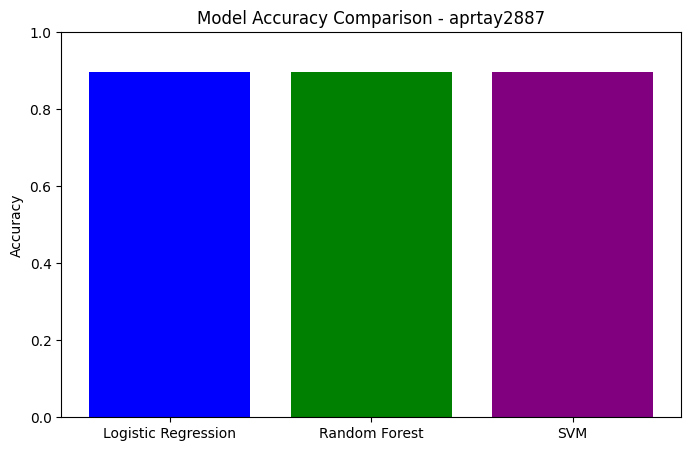

In [15]:
#Bar chart showing comparisons
plt.figure(figsize=(8,5))
plt.bar(accuracy_results.keys(), accuracy_results.values(), color=["blue", "green", "purple"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()


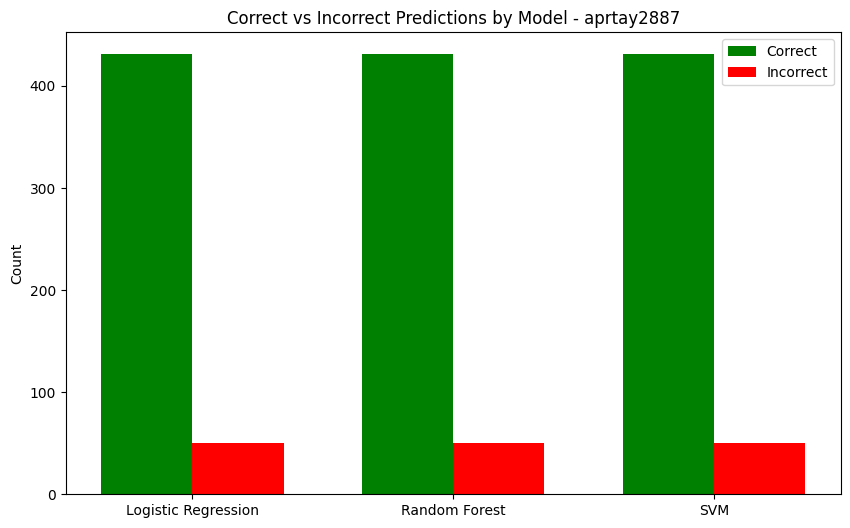

In [16]:
#Extract the model names and their correct/incorrect prediction counts
labels = list(correct_counts.keys())
correct_vals = list(correct_counts.values())
incorrect_vals = list(incorrect_counts.values())

#Set up bar positions and bar width
x = np.arange(len(labels))
width = 0.35

#Bar chart comapring correct and incorrect predictions
plt.figure(figsize=(10,6))
plt.bar(x - width/2, correct_vals, width, label="Correct", color="green")
plt.bar(x + width/2, incorrect_vals, width, label="Incorrect", color="red")
plt.xticks(x, labels)
plt.ylabel("Count")
plt.title("Correct vs Incorrect Predictions by Model")
plt.legend()
plt.show()